In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Task 1 — Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_excel("/content/Concrete_Data.xls")
print(df.head())

   Cement (component 1)(kg in a m^3 mixture)  \
0                                      540.0   
1                                      540.0   
2                                      332.5   
3                                      332.5   
4                                      198.6   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                0.0       
1                                                0.0       
2                                              142.5       
3                                              142.5       
4                                              132.4       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   Water  (component 4)(kg in a m^3 mixture)  \
0      

In [4]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns)
print(df.info())
print(df.describe())

Dataset shape: (1030, 9)
Columns: Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component

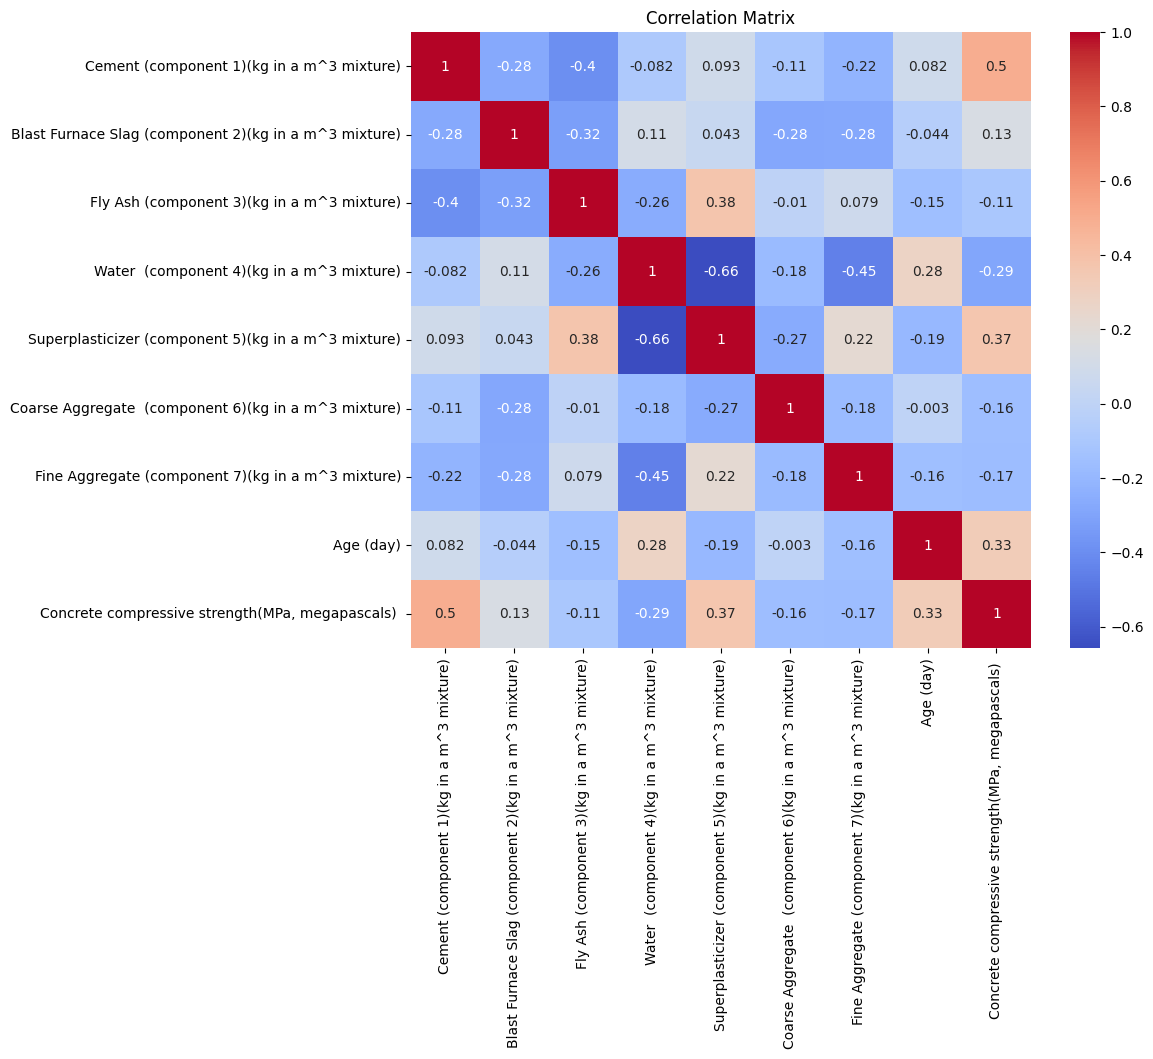

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
print(df.isnull().sum())

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


# Task 2 — Data Cleaning & Transformation

In [31]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

Cement (component 1)(kg in a m^3 mixture) : 0
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 2
Fly Ash (component 3)(kg in a m^3 mixture) : 0
Water  (component 4)(kg in a m^3 mixture) : 9
Superplasticizer (component 5)(kg in a m^3 mixture) : 10
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 0
Fine Aggregate (component 7)(kg in a m^3 mixture) : 5
Age (day) : 59
Concrete compressive strength(MPa, megapascals)  : 4


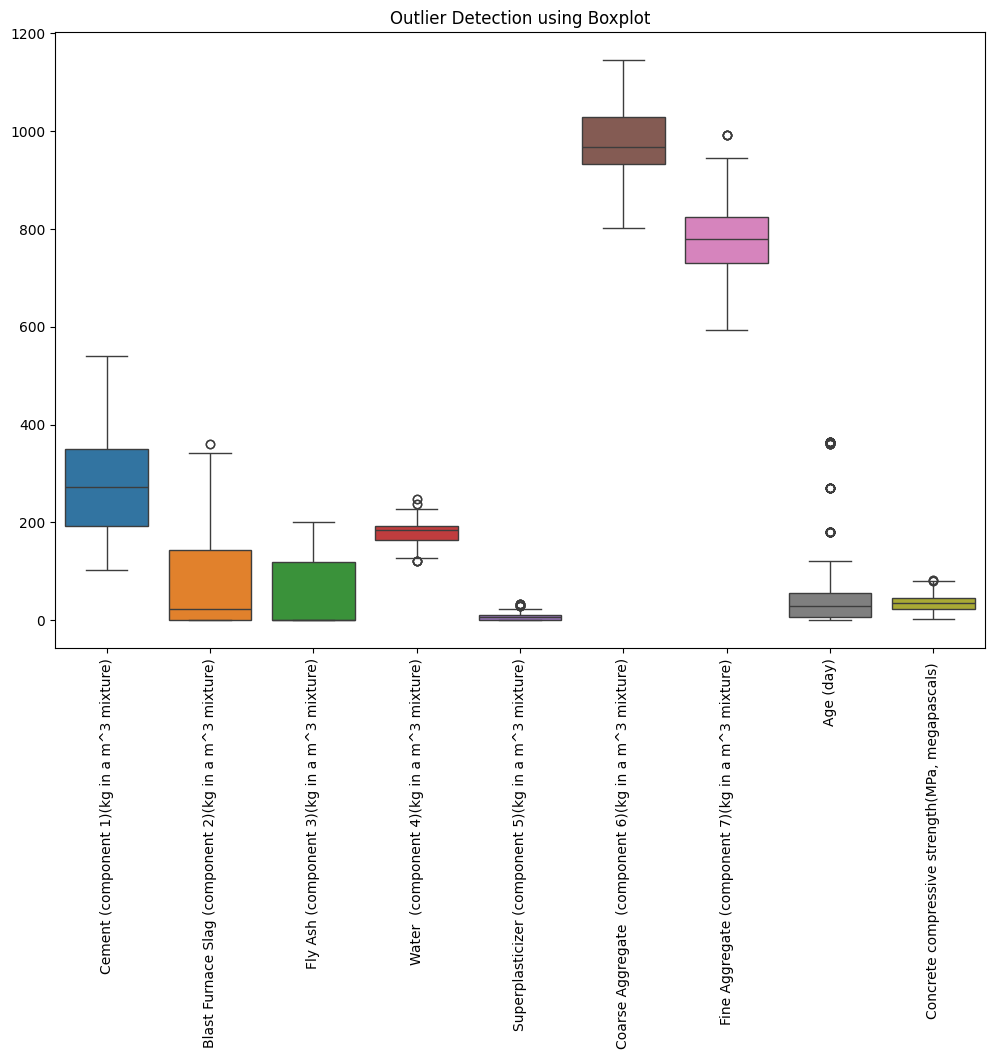

In [32]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplot")
plt.show()

# Task 3 — Simple Linear Regression

We select one feature: Cement.

In [17]:
scaler = StandardScaler()
X = df.drop("Concrete compressive strength(MPa, megapascals) ", axis=1)
y = df["Concrete compressive strength(MPa, megapascals) "]
X_scaled = scaler.fit_transform(X)

In [18]:
X_simple = df[["Cement (component 1)(kg in a m^3 mixture)"]]
y = df["Concrete compressive strength(MPa, megapascals) "]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

In [20]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = model_simple.predict(X_test)

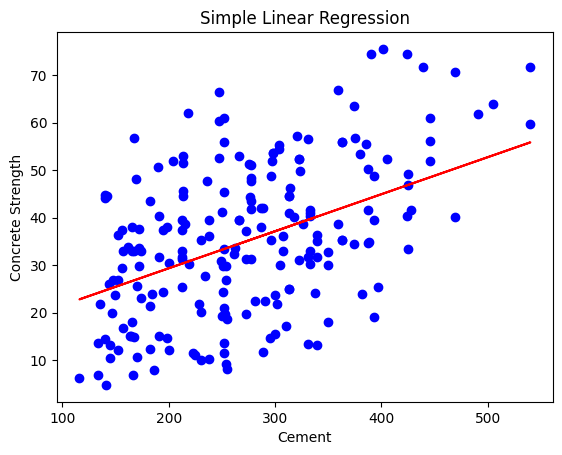

In [22]:
plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, y_pred, color="red")
plt.xlabel("Cement")
plt.ylabel("Concrete Strength")
plt.title("Simple Linear Regression")
plt.show()

In [23]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.25183140674244187
MAE: 11.555820769998833
MSE: 192.78889718821986
RMSE: 13.884844154264744


# Task 4 — Multiple Linear Regression

Now use all features.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [25]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred_multi = model_multi.predict(X_test)

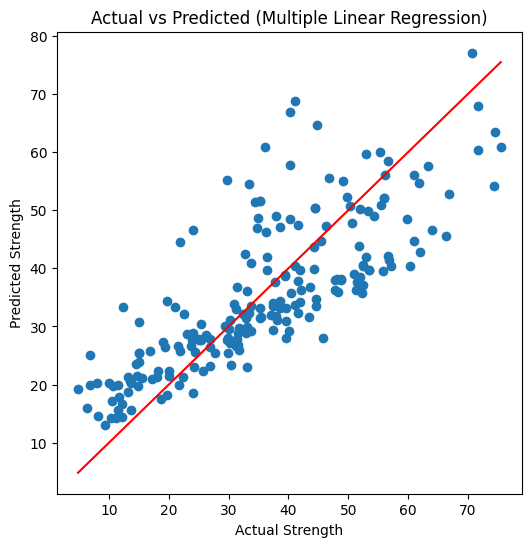

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_multi)

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted (Multiple Linear Regression)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [28]:
r2 = r2_score(y_test, y_pred_multi)
mae = mean_absolute_error(y_test, y_pred_multi)
mse = mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.6275416055429017
MAE: 7.745392872421349
MSE: 95.97548435337715
RMSE: 9.79670783239845
